# Sampling Methods and Central Limit Theorem
**Dr. Dave Wanik - University of Connecticut**

--------------------------------------------------------------------------
In this notebook, we will discuss methods of selecting a sample from a population. Next, we construct a distribution of the sample mean to understand how the sample means tend to cluster around the population mean. Finally, we will show that for any population the shape of this sampling distribution tends to follow the normal probability distribution (regardless of the original distribution!).

In [1]:
# https://drive.google.com/file/d/1kl0eEcPyWcLKldDyPv7u9nSjGCmdi138/view?usp=sharing
!gdown 1kl0eEcPyWcLKldDyPv7u9nSjGCmdi138

Downloading...
From: https://drive.google.com/uc?id=1kl0eEcPyWcLKldDyPv7u9nSjGCmdi138
To: /content/weight-height.csv
100% 418k/418k [00:00<00:00, 107MB/s]


In [8]:
import matplotlib.pyplot as plt

# Introduction
Everything we have done up until this point is preparing us for 'inferential statistics' - how to determine something about a population by using a sample.

A sample is a portion or part of the population of
interest. In many cases, sampling is more feasible than studying the entire population. These are some reasons why we sample:
* Contacting an entire population is time-consuming
* Cost may be prohibitively expensive
* Some populations are infinite - like measuring the water in a lake (so we instead measure at random sample locations)

The most widely used type of sampling is **simple random sampling**, where a sample is selected such that each item (or person) in the sample has an equal chance of being included.

Other types of sampling (like systematic random sampling, stratified random sampling and clsuter sampling are described in your book).




# Sampling "Error"
Samples are used to estimate population characteristics. For example, the mean of a sample is used to estimate the population mean. However, since the sample is a part or portion of the population, it is unlikely that the sample mean would be exactly equal to the population mean.

Similarly, it is unlikely that the sample standard deviation would be exactly equal to the population standard deviation. We can
therefore expect a difference between a sample statistic and its corresponding population parameter. This difference is called **sampling error**.

## Example: `weight-height` dataset from R
There is a dataset called `weight-height` that is part of base R. Let's use it to explore the concept of a sampling distribution.

In [2]:
import pandas as pd
df = pd.read_csv('/content/weight-height.csv')
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [3]:
df # show the dataframe

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


In [4]:
df.columns

Index(['Gender', 'Height', 'Weight'], dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Gender  10000 non-null  object 
 1   Height  10000 non-null  float64
 2   Weight  10000 non-null  float64
dtypes: float64(2), object(1)
memory usage: 234.5+ KB


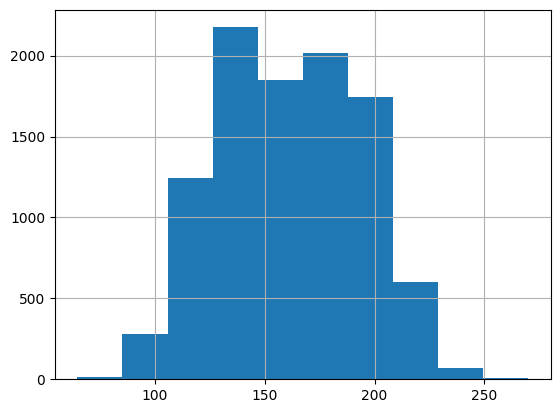

In [9]:
# look at this as a hist plot - this is normally distributed dataset
df['Weight'].hist()
plt.show()

Let’s consider this data as the population of interest. This is just for illustration. Normally, populations are
not this small or even finite. Assuming this is the population, the population mean is


In [10]:
 popmean = df['Weight'].mean()
 popmean

161.44035683283076

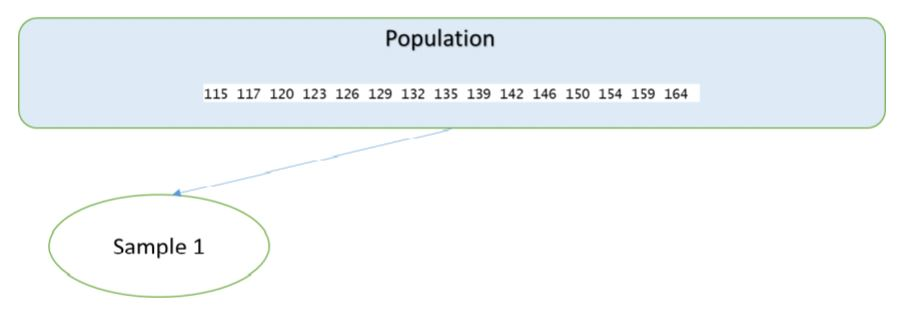

Let’s draw a sample of 5 people from this population and compute the mean of the sample.

In [16]:
# this is one sample - you can run it 5 times!
sampleMean = df['Weight'].sample(n=5).mean()
print(sampleMean)

144.9155627030296


If we know what the population mean is (161.4), we can calculate the sampling error.

In [17]:
# pop mean - sample mean
sampErr = popmean - df['Weight'].sample(n=5).mean()
sampErr
# you may get slightly different results due to sampling, this is OK!

16.843448097325364

You can run the above code a few times to get a feel for how things are working.

The sample mean is probably a bit different from the population mean. A question that comes up is how close or how far the sample mean can be from the true population mean. Rather than doing a single sample, let’s replicate this sample 10,000 times.

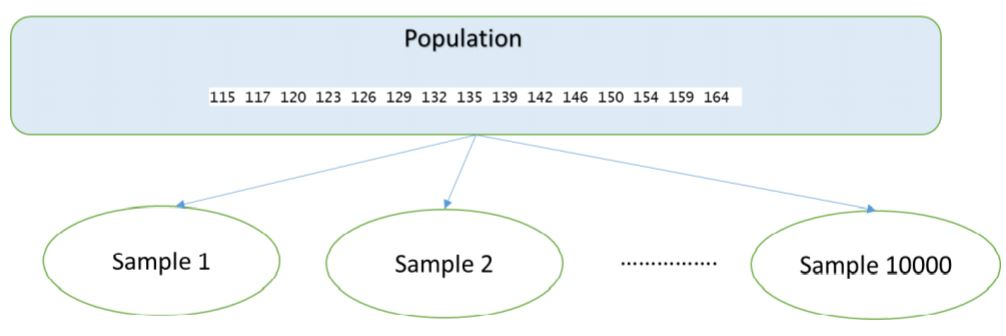

If you run this code, you will get different sample means every time...

In [22]:
import numpy as np

def f1():
    s = np.mean(np.random.choice(df['Weight'], size=5, replace=False))
    return s

meandist = np.array([f1() for a in range(100)]) #run it 100 times!

# here is the distribution of your sample means (with size = 5)
meandist # 100 sample means


array([155.59590601, 175.80039885, 163.74782502, 152.86662376,
       195.98744714, 161.77523514, 183.29687595, 184.55633678,
       160.49672061, 201.92921154, 167.68186687, 157.48697682,
       154.29454938, 156.26459877, 173.17269858, 170.36197489,
       155.63616079, 137.55864473, 166.62073604, 168.19031736,
       177.11268523, 191.97840257, 160.93334915, 183.45431878,
       167.45993907, 166.55457447, 142.23024552, 170.97412869,
       163.50156494, 187.89469858, 158.6686198 , 172.32304975,
       154.98179771, 157.43137362, 188.49002088, 156.87361829,
       152.98182824, 126.9546641 , 168.52071294, 158.89644022,
       159.703947  , 152.47362381, 139.36415331, 161.44286474,
       150.49657063, 152.11018352, 160.97145989, 162.00988801,
       161.3817507 , 157.33314541, 178.92786758, 161.56065042,
       171.05370529, 150.7720999 , 167.88861727, 141.6692228 ,
       171.22868949, 159.02916996, 180.96481924, 150.88602098,
       166.69234894, 159.37481364, 169.98597678, 159.79

... but the average of the sample means should be pretty darn constant - especially as the repetitions increase or the sample size increases.

In [23]:
np.mean(meandist)

164.19905366509488

How low and how high can the sample means be?

In [24]:
# smallest mean from a synthetic sample
min(meandist)

121.48328592131232

In [25]:
# largest mean from a synthetic sample
max(meandist)

201.92921153781498

Interestingly, the **mean of the means** is pretty close to the true population mean.

In [26]:
# the mean of means
print(np.mean(meandist))
# the pop mean
print(popmean)

164.19905366509488
161.44035683283076


Let’s plot the sample means.

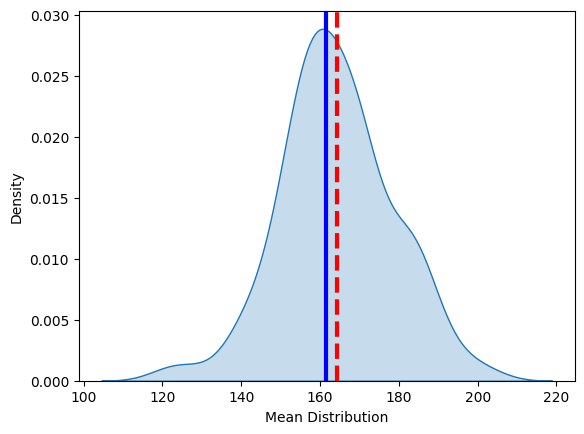

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a KDE plot using Seaborn
sns.kdeplot(meandist, label='Density', fill=True)

# Add the actual population mean
popmean = np.mean(df['Weight'])
plt.axvline(x=popmean, color='blue', linewidth=3, label='Population Mean')

# Add the mean of means
mean_of_means = np.mean(meandist)
plt.axvline(x=mean_of_means, color='red', linewidth=3, linestyle='--', label='Mean of Means')

# Add labels and legend
plt.xlabel('Mean Distribution')
plt.show()


The above is called a **sampling distribution**. You will also notice that the shape of the sampling
distribution looks normal.

The `popmean` and `mean(meandist))` are right on top of each other! So, we can collect a bunch of samples and calculate the mean of the sample, or we can collect one sample and then create a ton of SYNTHETIC samples and get the same mean as the population mean.

This is moving in the right step towards inferential statistics! You are inferring something about the population by using a sample (or samples).

Let’s compute the following probabilities.
1. What is the probability that a sample drawn from this population will have a sample mean of
less than 125?
2. What is the probability that a sample drawn from this population will have a sample mean of
greater than 145?


In [28]:
# Count the number of observations less than 125
count_below_125 = np.sum(meandist < 125)

# Calculate the proportion
proportion_below_125 = count_below_125 / len(meandist)

# Display the result
print(proportion_below_125)

0.01


In [29]:
# Count the number of observations greater than 145
count_above_145 = np.sum(meandist > 145)

# Calculate the proportion
proportion_above_145 = count_above_145 / len(meandist)

# Display the result
print(proportion_above_145)


0.93


# Central Limit Theorem

If all samples of a particular size are selected from any population, the sampling distribution of the sample mean is approximately a normal distribution. This approximation improves with larger samples.

This means to for ANY distribution, the distribution of sample means will be NORMAL. This is a huge discovery... and will set us up for success with inferential statistics.


# Standard Error of the Mean
The central limit theorem itself **does not** say
anything about the dispersion of the sampling distribution of the sample mean or
about the comparison of the mean of the sampling distribution of the sample mean
to the mean of the population.

However, we can observe that there was less dispersion in the distribution of the sample mean than
in the population distribution by noting the difference in the range in the population
and the range of the sample means.

We observe that the mean of the sample means
is close to the mean of the population. It can be demonstrated that the mean of
the sampling distribution is the population mean ($\mu_\bar{X} = \mu$, and if the standard
deviation in the population is $\sigma$, the standard deviation of the sample means is $\sigma/\sqrt{n}$
where n is the number of observations in each sample. We refer to $\sigma/\sqrt{n}$ as the
**standard error of the mean**. Its longer name is actually the *standard deviation of
the sampling distribution of the sample mean.*

$\sigma_\bar{X} = \frac{\sigma}{\sqrt{n}}$

Two important conclusions:
1. The mean of the distribution of sample means will be exactly equal to the population mean if we are able to select all possible samples of the same size from
a given population. That is: $\mu = \mu_\bar{X}$
Even if we do not select all samples, we can expect the mean of the distribution of sample means to be close to the population mean.
2. There will be less dispersion in the sampling distribution of the sample mean
than in the population. If the standard deviation of the population is $\sigma$, the standard deviation of the distribution of sample means is $\frac{\sigma}{\sqrt{n}}$. **Note that when we
increase the size of the sample, the standard error of the mean decreases.**

In [30]:
print(np.std(df['Weight'])) # this is the standard deviation of the raw data
print(np.std(meandist)) # this is the standard deviation of the sampling distribution (100 sample means)

32.106833544431716
14.155122620564747


See how the sd of the sampling distribution is smaller than the raw data? A nice property!

## Example: Uniform Distribution

Population Mean: 200.12694806085338


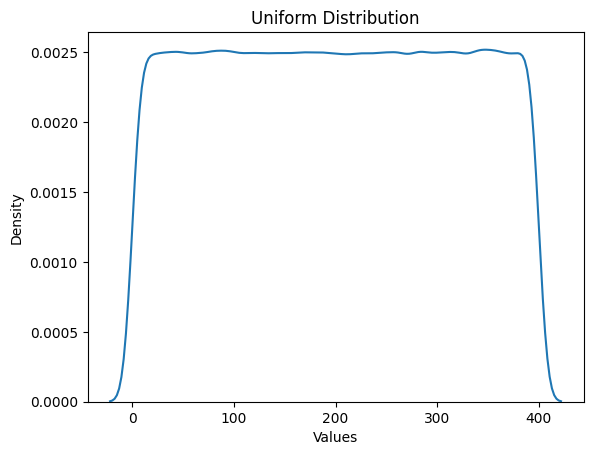

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform

# Generate uniform distribution
unif = np.random.uniform(0, 400, 1000000)

# Plot the density of the uniform distribution
sns.kdeplot(unif, label='Density')
plt.title('Uniform Distribution')
plt.xlabel('Values')
plt.ylabel('Density')

# Calculate and print the population mean
pop_mean_u = np.mean(unif)
print("Population Mean:", pop_mean_u)

# Show the plot
plt.show()


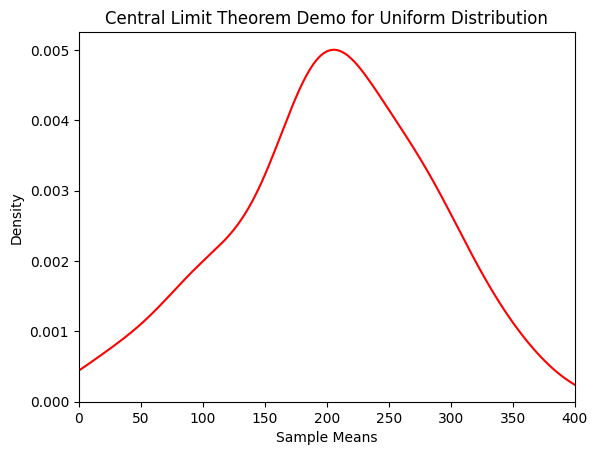

In [32]:
# Set seed for reproducibility
np.random.seed(42)

# Number of samples
num_samples = 50

# Generate samples of size 2 from the uniform distribution
sim_2_u = np.array([np.mean(np.random.choice(unif, size=2, replace=False)) for _ in range(num_samples)])

# Plot the density of the sample means
sns.kdeplot(sim_2_u, color='red')
plt.title('Central Limit Theorem Demo for Uniform Distribution')
plt.xlabel('Sample Means')
plt.ylabel('Density')
plt.xlim(0, 400)

# Show the plot
plt.show()


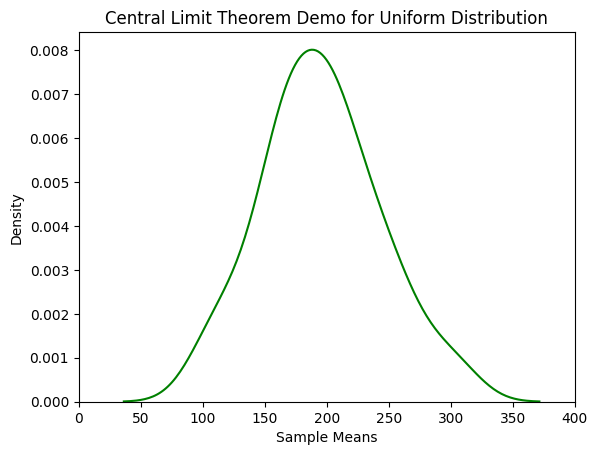

In [33]:
# Generate samples of size 6 from the uniform distribution
sim_6_u = np.array([np.mean(np.random.choice(unif, size=6, replace=False)) for _ in range(num_samples)])

# Plot the density of the sample means
sns.kdeplot(sim_6_u, color='green')
plt.title('Central Limit Theorem Demo for Uniform Distribution')
plt.xlabel('Sample Means')
plt.ylabel('Density')
plt.xlim(0, 400)

# Show the plot
plt.show()


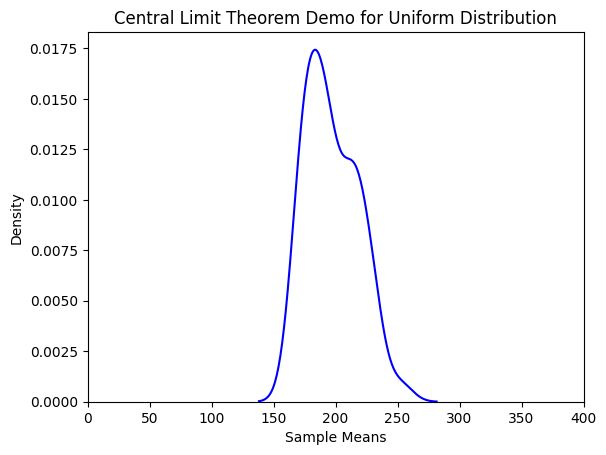

In [34]:
# Generate samples of size 30 from the uniform distribution
sim_30_u = np.array([np.mean(np.random.choice(unif, size=30, replace=False)) for _ in range(num_samples)])

# Plot the density of the sample means
sns.kdeplot(sim_30_u, color='blue')
plt.title('Central Limit Theorem Demo for Uniform Distribution')
plt.xlabel('Sample Means')
plt.ylabel('Density')
plt.xlim(0, 400)

# Show the plot
plt.show()


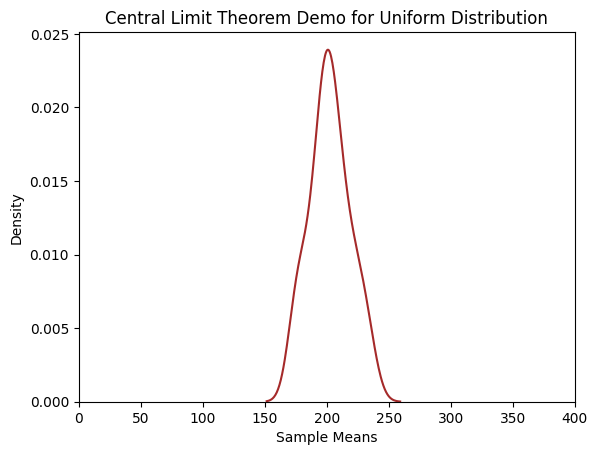

In [35]:
# Generate samples of size 50 from the uniform distribution
sim_50_u = np.array([np.mean(np.random.choice(unif, size=50, replace=False)) for _ in range(num_samples)])

# Plot the density of the sample means
sns.kdeplot(sim_50_u, color='brown')
plt.title('Central Limit Theorem Demo for Uniform Distribution')
plt.xlabel('Sample Means')
plt.ylabel('Density')
plt.xlim(0, 400)

# Show the plot
plt.show()

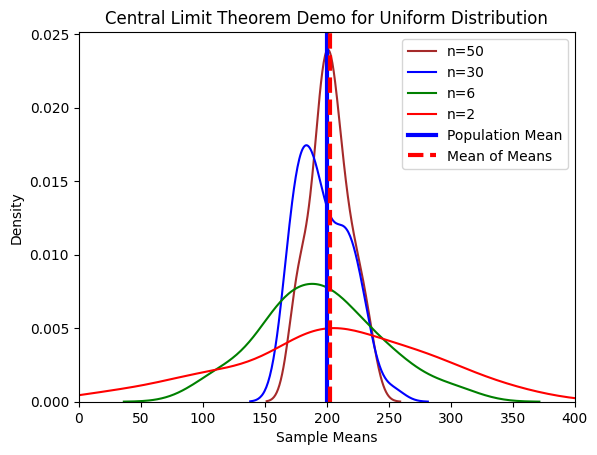

In [36]:
# Plot the density of all the sampling distributions for a uniform distribution
sns.kdeplot(sim_50_u, color='brown', label='n=50')
sns.kdeplot(sim_30_u, color='blue', label='n=30')
sns.kdeplot(sim_6_u, color='green', label='n=6')
sns.kdeplot(sim_2_u, color='red', label='n=2')

# Add vertical lines for the actual population mean and mean of means
plt.axvline(x=pop_mean_u, color='blue', linewidth=3, label='Population Mean')
plt.axvline(x=np.mean(sim_50_u), color='red', linewidth=3, linestyle='--', label='Mean of Means')

# Set plot properties
plt.title('Central Limit Theorem Demo for Uniform Distribution')
plt.xlabel('Sample Means')
plt.ylabel('Density')
plt.xlim(0, 400)
plt.legend()

# Show the plot
plt.show()


In [37]:
print(np.mean(sim_50_u))
print(pop_mean_u)

# pretty close!

202.54602893621254
200.12694806085338


## Example: Exponential Distribution

Population Mean: 14.987093669058446


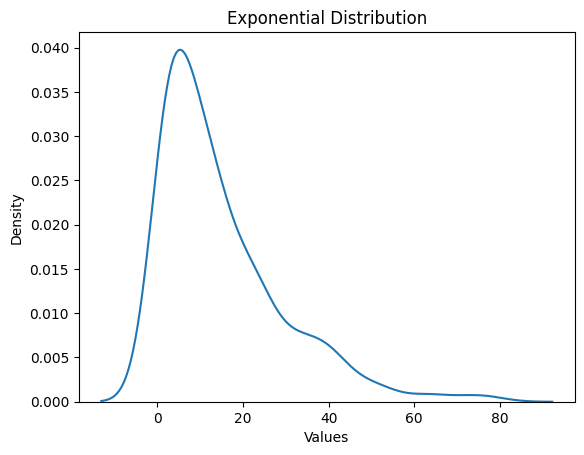

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import expon

# Generate exponential distribution
exp = np.random.exponential(scale=15, size=400)

# Plot the density of the exponential distribution
sns.kdeplot(exp, label='Density')
plt.title('Exponential Distribution')
plt.xlabel('Values')
plt.ylabel('Density')

# Calculate and print the population mean
pop_mean_e = np.mean(exp)
print("Population Mean:", pop_mean_e)

# Show the plot
plt.show()


In [54]:
# Set seed for reproducibility
np.random.seed(42)

# Generate samples of size 2 from the exponential distribution
sim_2_e = np.array([np.mean(np.random.choice(exp, size=2, replace=False)) for _ in range(num_samples)])

# Calculate the sample means
n_2_e = np.mean(sim_2_e, axis=0)

# Display the result
print(n_2_e)


13.479081219120653


In [56]:
# Generate samples of size 6 from the exponential distribution
sim_6_e = np.array([np.mean(np.random.choice(exp, size=6, replace=False)) for _ in range(num_samples)])

# Calculate the sample means
n_6_e = np.mean(sim_6_e, axis=0)

# Display the result
print(n_6_e)


13.998554595032351


In [57]:
# Generate samples of size 30 from the exponential distribution
sim_30_e = np.array([np.mean(np.random.choice(exp, size=30, replace=False)) for _ in range(num_samples)])

# Calculate the sample means
n_30_e = np.mean(sim_30_e, axis=0)

# Display the result
print(n_30_e)


14.997342027732923


In [58]:
# Generate samples of size 50 from the exponential distribution
sim_50_e = np.array([np.mean(np.random.choice(exp, size=50, replace=False)) for _ in range(num_samples)])

# Calculate the sample means
n_50_e = np.mean(sim_50_e, axis=0)

# Display the result
print(n_50_e)


14.967901884493612


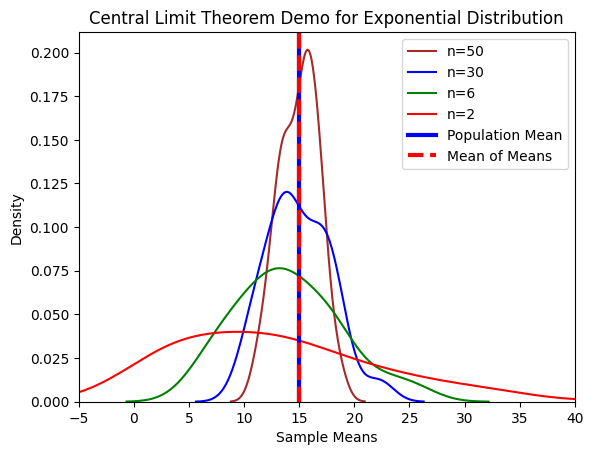

In [59]:
# Plot the density of all the sampling distributions for an Exponential distribution
sns.kdeplot(sim_50_e, color='brown', label='n=50')
sns.kdeplot(sim_30_e, color='blue', label='n=30')
sns.kdeplot(sim_6_e, color='green', label='n=6')
sns.kdeplot(sim_2_e, color='red', label='n=2')

# Add vertical lines for the actual population mean and mean of means
plt.axvline(x=pop_mean_e, color='blue', linewidth=3, label='Population Mean')
plt.axvline(x=np.mean(n_50_e), color='red', linewidth=3, linestyle='--', label='Mean of Means')

# Set plot properties
plt.title('Central Limit Theorem Demo for Exponential Distribution')
plt.xlabel('Sample Means')
plt.ylabel('Density')
plt.xlim(-5, 40)
plt.legend()

# Show the plot
plt.show()


## Example: Normal Distribution

Population Mean: -0.013496564718576878


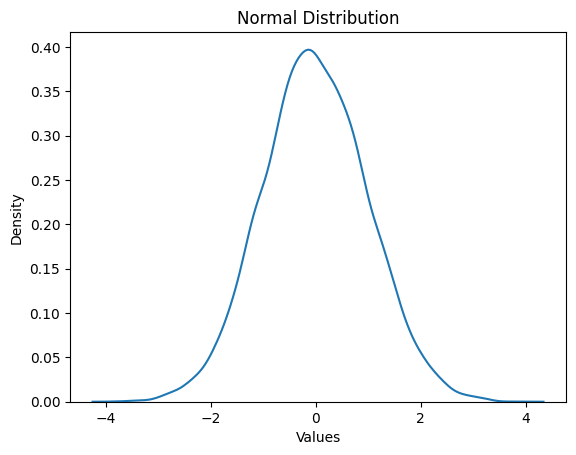

In [60]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Generate normal distribution
nor = np.random.normal(size=10000)

# Plot the density of the normal distribution
sns.kdeplot(nor, label='Density')
plt.title('Normal Distribution')
plt.xlabel('Values')
plt.ylabel('Density')

# Calculate and print the population mean
pop_mean_n = np.mean(nor)
print("Population Mean:", pop_mean_n)

# Show the plot
plt.show()


In [61]:
# Set seed for reproducibility
np.random.seed(42)

# Generate samples of size 2 from the normal distribution
sim_2_n = np.array([np.mean(np.random.choice(nor, size=2, replace=False)) for _ in range(num_samples)])

# Calculate the sample means
n_2_n = np.mean(sim_2_n, axis=0)

# Display the result
print(n_2_n)


0.08371422050643203


In [62]:
# Generate samples of size 6 from the normal distribution
sim_6_n = np.array([np.mean(np.random.choice(nor, size=6, replace=False)) for _ in range(num_samples)])

# Calculate the sample means
n_6_n = np.mean(sim_6_n, axis=0)

# Display the result
print(n_6_n)


-0.07533605568399337


In [63]:
# Generate samples of size 30 from the normal distribution
sim_30_n = np.array([np.mean(np.random.choice(nor, size=30, replace=False)) for _ in range(num_samples)])

# Calculate the sample means
n_30_n = np.mean(sim_30_n, axis=0)

# Display the result
print(n_30_n)


-0.01107254952896507


In [64]:
# Generate samples of size 50 from the normal distribution
sim_50_n = np.array([np.mean(np.random.choice(nor, size=50, replace=False)) for _ in range(num_samples)])

# Calculate the sample means
n_50_n = np.mean(sim_50_n, axis=0)

# Display the result
print(n_50_n)


-0.04282246344044828


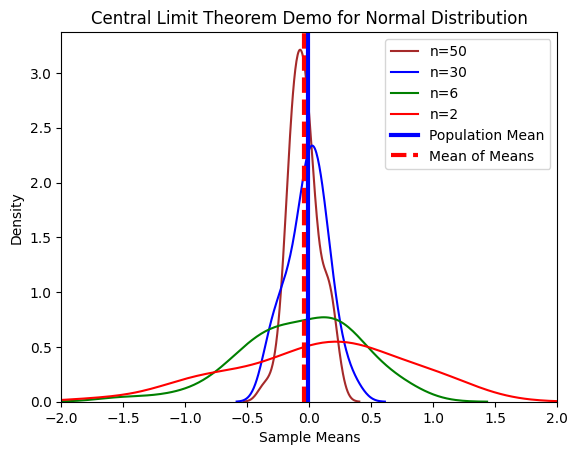

In [65]:
# Plot the density of all the sampling distributions for a normal distribution
sns.kdeplot(sim_50_n, color='brown', label='n=50')
sns.kdeplot(sim_30_n, color='blue', label='n=30')
sns.kdeplot(sim_6_n, color='green', label='n=6')
sns.kdeplot(sim_2_n, color='red', label='n=2')

# Add vertical lines for the actual population mean and mean of means
plt.axvline(x=pop_mean_n, color='blue', linewidth=3, label='Population Mean')
plt.axvline(x=np.mean(n_50_n), color='red', linewidth=3, linestyle='--', label='Mean of Means')

# Set plot properties
plt.title('Central Limit Theorem Demo for Normal Distribution')
plt.xlabel('Sample Means')
plt.ylabel('Density')
plt.xlim(-2, 2)
plt.legend()

# Show the plot
plt.show()


The central limit theorem therefore, indicates that, regardless of the shape of the population distribution, the sampling distribution of the sample mean will move toward the normal probability distribution.<br>The larger the number of observations in each sample, the stronger the convergence.


# All together!

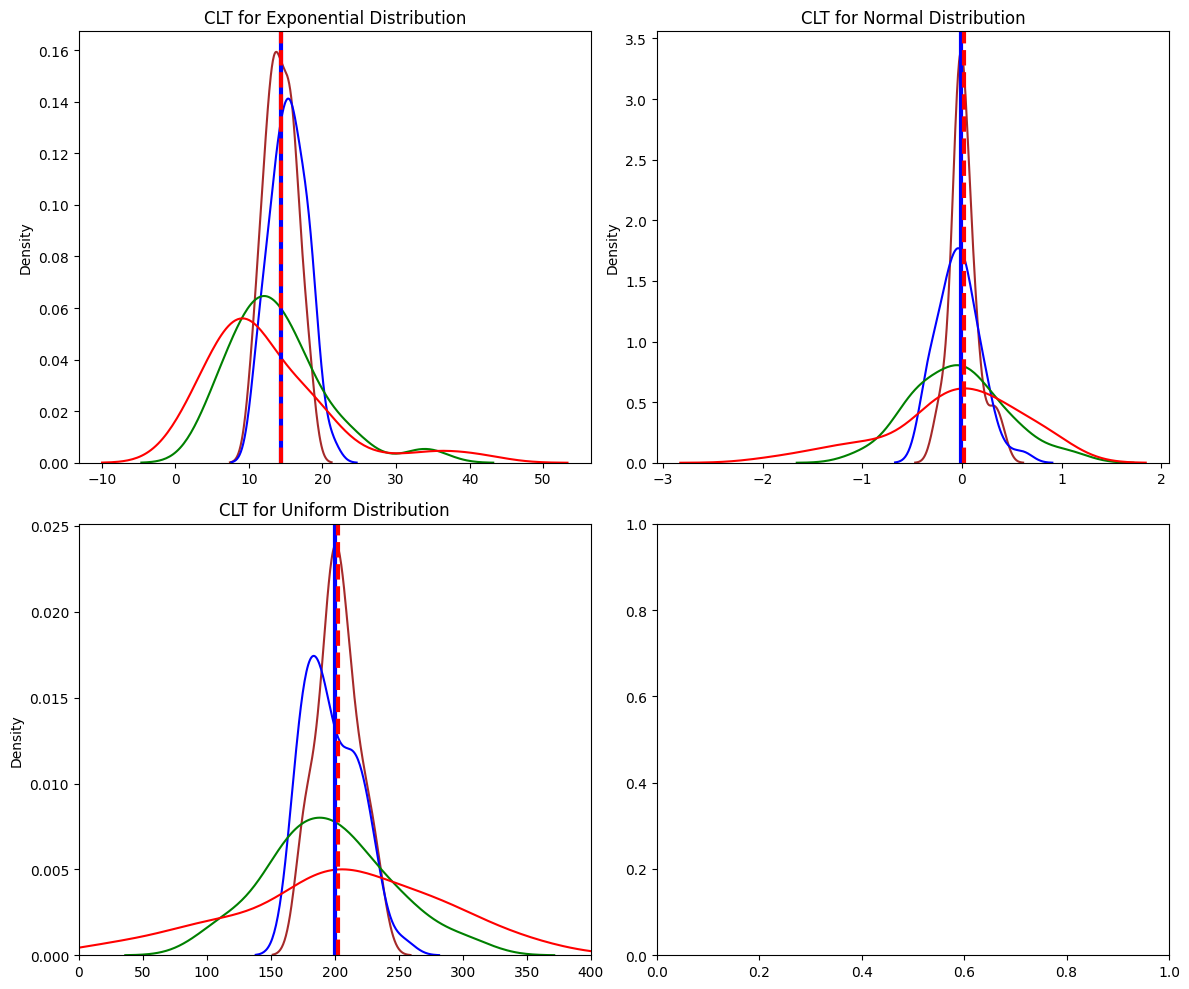

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set up a 2x2 grid for subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Exponential Distribution
sns.kdeplot(sim_50_e, color='brown', ax=axes[0, 0])
sns.kdeplot(sim_30_e, color='blue', ax=axes[0, 0])
sns.kdeplot(sim_6_e, color='green', ax=axes[0, 0])
sns.kdeplot(sim_2_e, color='red', ax=axes[0, 0])
axes[0, 0].axvline(x=pop_mean_e, color='blue', linewidth=3, label='Population Mean')
axes[0, 0].axvline(x=np.mean(sim_50_e), color='red', linewidth=3, linestyle='--', label='Mean of Means')
axes[0, 0].set_title('CLT for Exponential Distribution')

# Normal Distribution
sns.kdeplot(sim_50_n, color='brown', ax=axes[0, 1])
sns.kdeplot(sim_30_n, color='blue', ax=axes[0, 1])
sns.kdeplot(sim_6_n, color='green', ax=axes[0, 1])
sns.kdeplot(sim_2_n, color='red', ax=axes[0, 1])
axes[0, 1].axvline(x=pop_mean_n, color='blue', linewidth=3, label='Population Mean')
axes[0, 1].axvline(x=np.mean(sim_50_n), color='red', linewidth=3, linestyle='--', label='Mean of Means')
axes[0, 1].set_title('CLT for Normal Distribution')

# Uniform Distribution
sns.kdeplot(sim_50_u, color='brown', ax=axes[1, 0])
sns.kdeplot(sim_30_u, color='blue', ax=axes[1, 0])
sns.kdeplot(sim_6_u, color='green', ax=axes[1, 0])
sns.kdeplot(sim_2_u, color='red', ax=axes[1, 0])
axes[1, 0].axvline(x=pop_mean_u, color='blue', linewidth=3, label='Population Mean')
axes[1, 0].axvline(x=np.mean(sim_50_u), color='red', linewidth=3, linestyle='--', label='Mean of Means')
axes[1, 0].set_title('CLT for Uniform Distribution')
axes[1, 0].set_xlim(0, 400)

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()
